<center><h1>Batra_Raghav_HW2</h1></center>
<br>
<br>

Name: Raghav Batra
<br>
Github Username: 
<br>
USC ID: 3227519293

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [52]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [ ]:
df = pd.read_excel("../CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")


(9568, 5)
['AT', 'V', 'AP', 'RH', 'PE']
Number of rows: 9568
Number of cols: 5


### (b) Exploring the data

#### i. rows and columns

In [11]:
df.shape

print(df.shape)
print(df.columns.tolist())
df.head()

print(f"Number of rows: {df.shape[0]}")
print(f"Number of cols: {df.shape[1]}")

(9568, 5)
['AT', 'V', 'AP', 'RH', 'PE']
Number of rows: 9568
Number of cols: 5


Each row represents an hourly interval in the 2006-2011 year range of the powerplants operating conditions.
Each column represents one variable measured for that hour Temperature (AT), Ambient Pressure (AP),
Relative Humidity (RH) and Exhaust Vacuum (V), and
energy output (EP) of the plant.

#### ii. pairwise scatterplots of all the varianbles

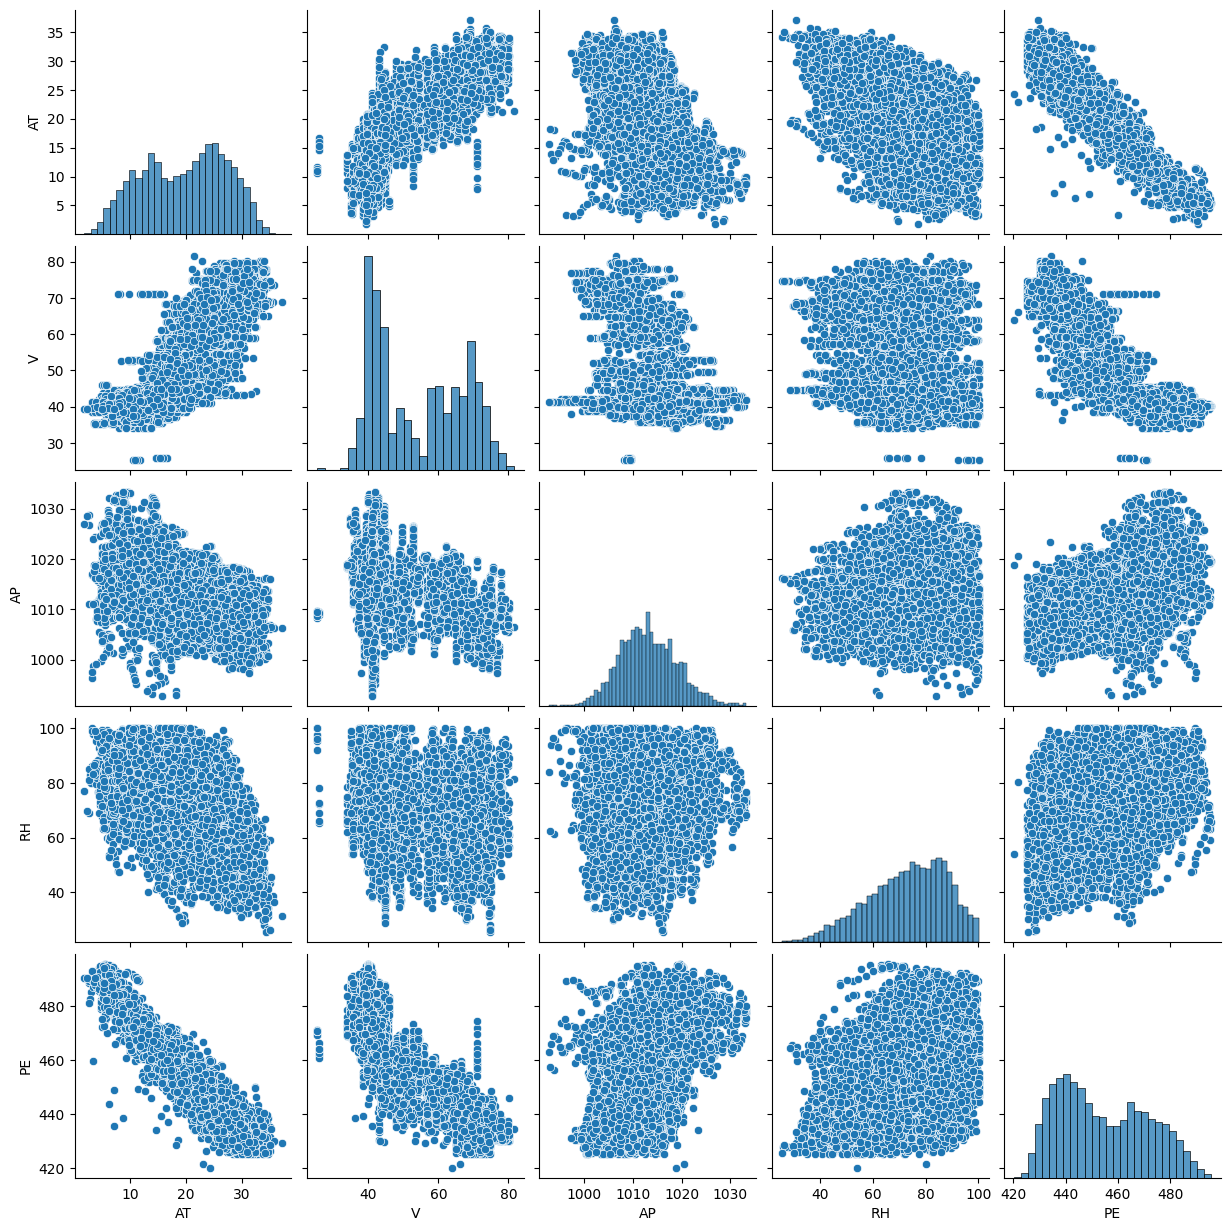

In [13]:
sb.pairplot(df)
plt.show()

AT vs PE: strong linear negative relationship

V vs PE: weaker than AT vs PE but also could be linear and negative relationship

AP vs PE: positive relationship but noisy might not be linear

RH vs PE: very noisy positive non linear relationship 

AT vs V: strong linear positive relationship 

AT vs RH: moderate negative linear relationship

AT vs AP, V vs AP, V vs RH, AP vs RH: weak scattered pattern little to no linear relationship


#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [14]:
summary = df.describe().T[['mean', '50%', '25%', '75%']]
summary.columns = ['Mean', 'Median', 'Q1', 'Q3']

summary['Range'] = df.max() - df.min()
summary['IQR'] = summary['Q3'] - summary['Q1']

summary = summary[['Mean', 'Median', 'Range', 'Q1', 'Q3', 'IQR']]
print(summary)

           Mean    Median  Range         Q1       Q3      IQR
AT    19.651231    20.345  35.30    13.5100    25.72  12.2100
V     54.305804    52.080  56.20    41.7400    66.54  24.8000
AP  1013.259078  1012.940  40.41  1009.1000  1017.26   8.1600
RH    73.308978    74.975  74.60    63.3275    84.83  21.5025
PE   454.365009   451.550  75.50   439.7500   468.43  28.6800


### (c) Simple Linear Regression

In [22]:
predictors = ['AT', 'V', 'AP', 'RH']
models = {}

for p in predictors:
    X = sm.add_constant(df[p])
    y = df['PE']
    models[p] = sm.OLS(y,X).fit()
    print(f"==={p}===")
    print(f"Coeff: {models[p].params[p]:.4f}")
    print(f"P-val: {models[p].pvalues[p]:.4f}")
    print(f"R-squared: {models[p].rsquared:.4f}")
    print()




===AT===
Coeff: -2.1713
P-val: 0.0000
R-squared: 0.8989

===V===
Coeff: -1.1681
P-val: 0.0000
R-squared: 0.7565

===AP===
Coeff: 1.4899
P-val: 0.0000
R-squared: 0.2688

===RH===
Coeff: 0.4557
P-val: 0.0000
R-squared: 0.1519



All 4 predictors show statistically significant association with PE since p < 0.00001 in each case. However the strength of these relationships varies greatly in the above table. With a sample size of n = 9568 even weak relationships will tend to be detected as statistically significant so Rsquared would be more meaningful of practical importance. 

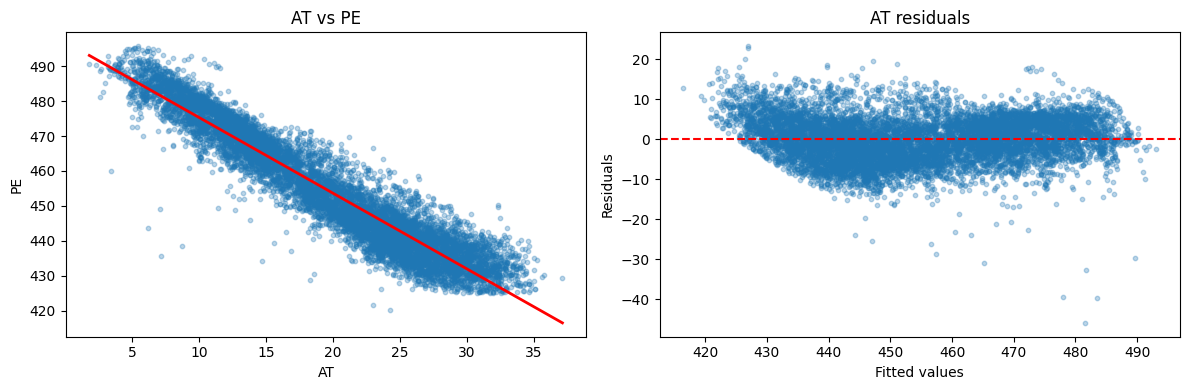

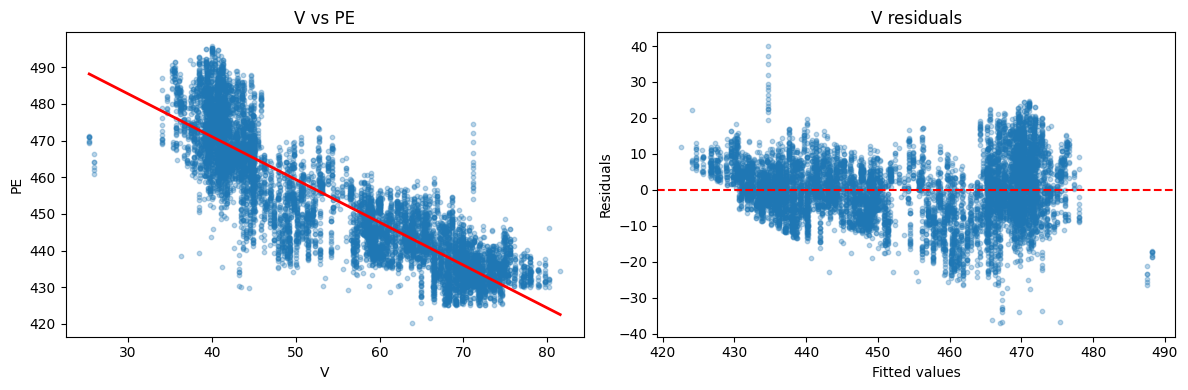

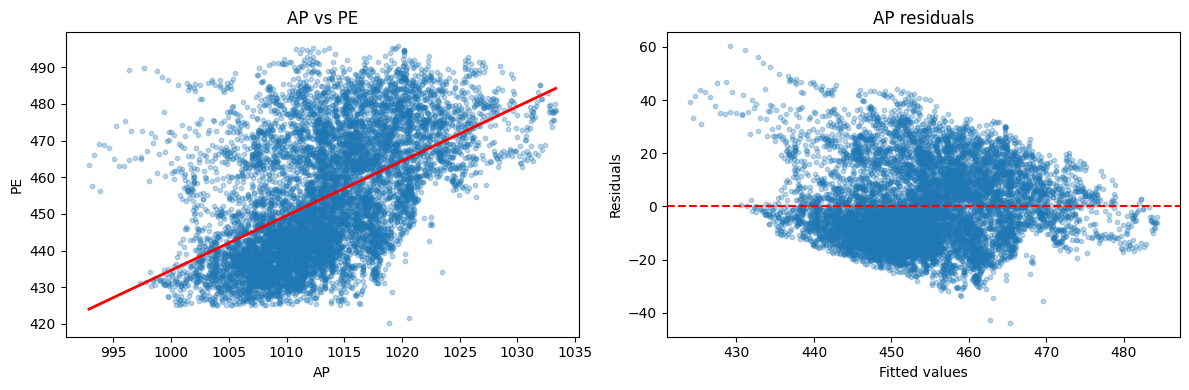

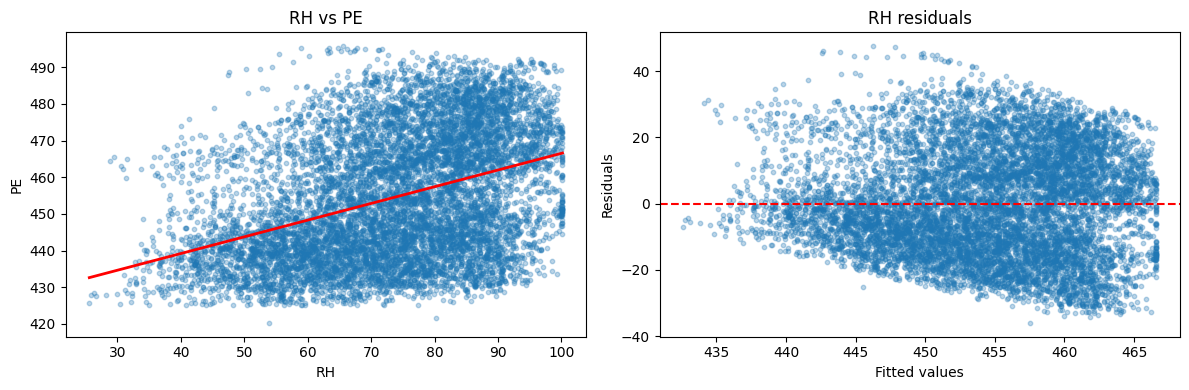

In [24]:
for p in predictors:
    fig,axes = plt.subplots(1,2, figsize=(12,4))
    #scatter and fit lines
    axes[0].scatter(df[p], df['PE'], alpha=0.3, s=10)
    x_range = np.linspace(df[p].min(), df[p].max(), 100)
    X_range= sm.add_constant(x_range)
    axes[0].plot(x_range, models[p].predict(X_range), color='red',linewidth=2)
    axes[0].set_xlabel(p)
    axes[0].set_ylabel('PE')
    axes[0].set_title(f'{p} vs PE')


    #residuals
    axes[1].scatter(models[p].fittedvalues, models[p].resid, alpha=0.3, s=10)
    axes[1].axhline(0, color = 'red', linestyle='--')
    axes[1].set_xlabel('Fitted values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'{p} residuals')

    plt.tight_layout()
    plt.show()
                        


In [28]:
for p in predictors:
    resid = models[p].resid
    threshold = 3 * resid.std()
    outliers = df[np.abs(resid) > threshold]
    pct = 100 * len(outliers)/len(df)
    print(f"{p}: {len(outliers)} outliers which is {pct:.2f}% of data")

AT: 42 outliers which is 0.44% of data
V: 33 outliers which is 0.34% of data
AP: 28 outliers which is 0.29% of data
RH: 2 outliers which is 0.02% of data


For outliers I used outliers as points beyond 3 sd of each models residuals.

### (d) Multiple Regression

In [29]:
X_multi = df[predictors]
X_multi = sm.add_constant(X_multi)
y = df['PE']

model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:59:58   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

The multi regression model gives Rsquared = 0.929 which is higher than any single predictor alone. All 4 predictors have p < 0.0001, so we reject the null meaning each contributes significantly. 

RH's coeef flips sign between simple (0.456) and multi model (-0.158) likely due to its correlation with AT counfounding the simple regression estimate

### (e) 1c Compare to 1d

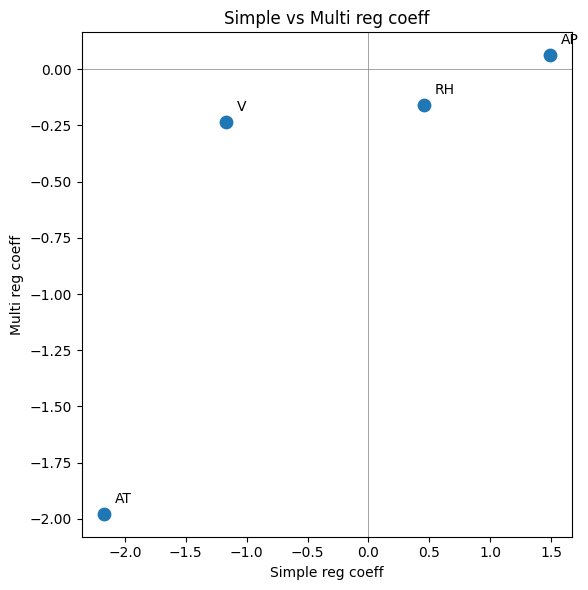

In [31]:
simple_coefs = [models[p].params[p] for p in predictors]
multi_coefs = [model_multi.params[p] for p in predictors]

plt.figure(figsize=(6,6))
plt.scatter(simple_coefs, multi_coefs, s=80)

for i,p in enumerate(predictors):
    plt.annotate(p, (simple_coefs[i], multi_coefs[i]), textcoords="offset points", xytext= (8,8))

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('Simple reg coeff')
plt.ylabel('Multi reg coeff')
plt.title('Simple vs Multi reg coeff')
plt.tight_layout()
plt.show()

In [32]:
comparison = pd.DataFrame({'simple coef': simple_coefs, 'multi_coef': multi_coefs}, index=predictors)
print(comparison)

    simple coef  multi_coef
AT    -2.171320   -1.977513
V     -1.168135   -0.233916
AP     1.489872    0.062083
RH     0.455650   -0.158054


AT changes little between models, while V and AP shrink substantially toward 0, and RH flips sign entirely which is evidence that V, AP, and RH simple coeff were confounded by their correlation with AT. 

### (f) Nonlinear Association

In [34]:
poly_models = {}

for p in predictors: 
    X_poly = pd.DataFrame({
        p: df[p],
        f'{p}^2': df[p]**2,
        f'{p}^3': df[p]**3
    })
    X_poly = sm.add_constant(X_poly)
    y = df['PE']

    poly_models[p] = sm.OLS(y, X_poly).fit()
    print(f"=== {p} cubic fit ===")
    print(poly_models[p].params)
    print(poly_models[p].pvalues)
    print(f"Rsquared: {poly_models[p].rsquared:.4f}")
    print()

=== AT cubic fit ===
const    492.728143
AT        -0.610346
AT^2      -0.125138
AT^3       0.002675
dtype: float64
const     0.000000e+00
AT        7.898147e-07
AT^2      8.833045e-73
AT^3     3.652185e-110
dtype: float64
Rsquared: 0.9119

=== V cubic fit ===
const    554.146849
V         -2.144377
V^2       -0.002712
V^3        0.000134
dtype: float64
const    0.000000
V        0.000025
V^2      0.768497
V^3      0.013735
dtype: float64
Rsquared: 0.7750

=== AP cubic fit ===
const     0.074694
AP       25.255593
AP^2     -0.049952
AP^3      0.000025
dtype: float64
const    4.502734e-17
AP       4.502735e-17
AP^2     3.666705e-17
AP^3     8.264146e-18
dtype: float64
Rsquared: 0.2749

=== RH cubic fit ===
const    468.413536
RH        -1.729211
RH^2       0.032145
RH^3      -0.000152
dtype: float64
const    0.000000
RH       0.000377
RH^2     0.000009
RH^3     0.000014
dtype: float64
Rsquared: 0.1537



/var/folders/zk/vwbf6t5d0fj4dl3xn399wpjw0000gn/T/ipykernel_88584/1946214959.py:12: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  poly_models[p] = sm.OLS(y, X_poly).fit()


Fitting a cubic model for each predictor shows the strongest evidence for nonlinearity for AT and V both show statistically significant quadratic or cubic terms (exception being V^2 was not significant as p=.77) alongside a meaningful R^2 improvement from simple linear fit (AT: 0.899->0.912, V: 0.757->0.775). AP and RH also show statistically significant higher order terms, but the R^2 gains are <1 suggesting the significance is a product of the larger sample size rather than a practically meaningful nonlinear relationship.

### (g) Interactions of Predictors

In [37]:
model_interact = smf.ols('PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH', data=df).fit()
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:42:47   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

AT:V - significant (p ~ 0)

AT:AP - not significant (p=.452)

AT:RH - significant (p ~ 0)

V:AP - significant (p ~ 0)

V:RH - not significant (p = 0.086 out of alpha=0.05 range)

AP:RH - significant (p=0.034)

### (h) Improvement

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

model1 = smf.ols('PE ~ AT + V + AP + RH', data=train_df).fit()

train_pred1 = model1.predict(train_df)
test_pred1 = model1.predict(test_df)

train_mse1 = mean_squared_error(train_df['PE'], train_pred1)
test_mse1 = mean_squared_error(test_df['PE'], test_pred1)

print(f"Model 1 (plain) - Train MSE: {train_mse1:.4f}, Test MSE: {test_mse1:.4f}")

formula_full = 'PE ~ AT + V + AP + RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2) + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH'
model2_full = smf.ols(formula_full, data=train_df).fit()


print(model2_full.summary())


Train size: 6697, Test size: 2871
Model 1 (plain) - Train MSE: 20.5808, Test MSE: 21.2399
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:59:44   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [46]:
formula_pruned = 'PE ~ AT + V + AP + RH + I(AT**2) + I(AP**2) + I(RH**2) + AT:V + AT:RH + AP:RH'
model2_pruned = smf.ols(formula_pruned, data=train_df).fit()

print(model2_pruned.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:04:16   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.046e+04   1091.512     -9.581      0.0

In [48]:
train_pred2 = model2_pruned.predict(train_df)
test_pred2 = model2_pruned.predict(test_df)

train_mse2 = mean_squared_error(train_df['PE'], train_pred2)
test_mse2 = mean_squared_error(test_df['PE'], test_pred2)

print(f"Model 2 (pruned) - Train MSE: {train_mse2:.4f}, Test MSE: {test_mse2:.4f}")




Model 2 (pruned) - Train MSE: 17.9178, Test MSE: 18.6943


### (i) KNN

best k raw: 5, Test MSE: 15.7268
best k normalized: 4, Test MSE: 14.3057


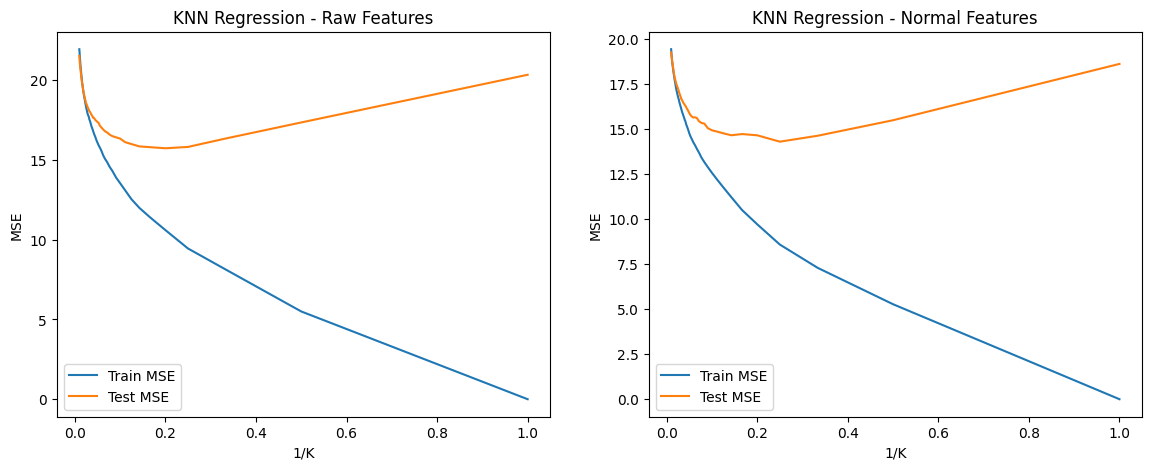

In [55]:
X_train_raw = train_df[predictors]
X_test_raw = test_df[predictors]
y_train = train_df['PE']
y_test = test_df['PE']

k_values = range(1,101)
train_mse_raw = []
test_mse_raw = []

for k in k_values: 
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_raw, y_train)

    train_mse_raw.append(mean_squared_error(y_train, knn.predict(X_train_raw)))
    test_mse_raw.append(mean_squared_error(y_test, knn.predict(X_test_raw)))


scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

train_mse_norm = []
test_mse_norm = []

for k in k_values: 
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_norm, y_train)

    train_mse_norm.append(mean_squared_error(y_train, knn.predict(X_train_norm)))
    test_mse_norm.append(mean_squared_error(y_test, knn.predict(X_test_norm)))

inv_k = [1/k for k in k_values]

fig,axes = plt.subplots(1,2,figsize=(14,5))

#raw features
axes[0].plot(inv_k, train_mse_raw, label='Train MSE')
axes[0].plot(inv_k, test_mse_raw, label='Test MSE')
axes[0].set_xlabel('1/K')
axes[0].set_ylabel('MSE')
axes[0].set_title('KNN Regression - Raw Features')
axes[0].legend()

#normal features
axes[1].plot(inv_k, train_mse_norm, label='Train MSE')
axes[1].plot(inv_k, test_mse_norm, label='Test MSE')
axes[1].set_xlabel('1/K')
axes[1].set_ylabel('MSE')
axes[1].set_title('KNN Regression - Normal Features')
axes[1].legend()

best_k_raw = k_values[test_mse_raw.index(min(test_mse_raw))]
best_k_norm = k_values[test_mse_norm.index(min(test_mse_norm))]

print(f"best k raw: {best_k_raw}, Test MSE: {min(test_mse_raw):.4f}")
print(f"best k normalized: {best_k_norm}, Test MSE: {min(test_mse_norm):.4f}")

### (j ) Compare KNN and Linear

In [57]:
comparison_final = pd.DataFrame({
    'Model': ['Plain Multiple Regression', 'Pruned Interaction/Quadratice Model', 'KNN (raw k = 5)', 'KNN (normalized, k=4)'],
    'Test MSE': [test_mse1, test_mse2, min(test_mse_raw), min(test_mse_norm)]
})
print(comparison_final)

                                 Model   Test MSE
0            Plain Multiple Regression  21.239857
1  Pruned Interaction/Quadratice Model  18.694346
2                      KNN (raw k = 5)  15.726820
3                KNN (normalized, k=4)  14.305669


KNN normalized performed the best as the test MSE was the lowest. This makes sense as KNN is non parametric and adapts to whatever the true relationship looks like without needing it to be specified in advance. 

However, this comes with tradeoffs as KNN provides no interpretable coefficients and cannot extrapolate beyond the training data's range. For accuracy KNN is a better choice, but for understanding how each variable drives plant output the regression model is more useful.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Flexible model works better since there is a large amount of samples so we have more than enough data to reliably estimate a flexible model with small number of p without overfitting

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Inflexible model because it has far fewer parameters, so it can be estimated reasonably well even with limited data, and it's less prone to chasing noise.

### (c) The relationship between the predictors and response is highly non-linear.

flexible model expected to perform better because it can actually represent that non-linearity, while an inflexible method is stuck with irreducible bias from a wrong assumption

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Inflexible model will work better as it is more rigid and constrained so it won't chase every wiggle in noisy data. A flexible model would instad overfit the noise itself, producing predictions with high cariance that don't generalize well.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [58]:
obs = {
    1: (0,3,0),
    2: (2,0,0),
    3: (0,1,3),
    4: (0,1,2),
    5: (-1,0,1),
    6: (1,1,1)
}

test_point = np.array([0,0,0])

for obs_num, coords in obs.items():
    dist = np.linalg.norm(np.array(coords) - test_point)
    print(f"Obs {obs_num}: distance = {dist:.4f}")

Obs 1: distance = 3.0000
Obs 2: distance = 2.0000
Obs 3: distance = 3.1623
Obs 4: distance = 2.2361
Obs 5: distance = 1.4142
Obs 6: distance = 1.7321


### (b) What is our prediction with K = 1? Why?

K = 1 choosing the closest distance obs to the test point so it is Obs5 with color green

### (c) What is our prediction with K = 3? Why?

K = 3 choosing the 3 closest distance obs to the test point so its Obs5,6,2 of that (green, red, red) Red wins the majority vote

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect small K to be the best value because the decision boundary will bend and flex to match local patterns closely, which is needed to approximate a highly non-linear true boundary. A large K would smooth everything into something closer to a simple near-linear boundary which would badly underfit a genuinely curvy Bayes Boundary. 